# **Spin-Resolved Density of States in SIESTA** 

## **What we are going to do**

We study magnetism using **spin-polarized DFT**.
We will:
1. Enable **spin-polarized calculations**
2. Build **three magnetic configurations**
   - FM (ferromagnetic)
   - AF1 ([001] layered antiferromagnetic)
   - AF2 ([111] antiferromagnetic, ground state)
3. Run self-consistent calculations for each phase
4. Compute the **spin-resolved density of states (DOS)**
5. Compare:
   - total energies
   - magnetic moments
   - DOS shapes
   - band gaps
---
##  **Magnetic phases considered**
###  **FM — Ferromagnetic**
All Mn spins parallel  
- net magnetization ≠ 0  
---
###  **AF1 — [001] layered antiferromagnetic**
Alternate spin direction between consecutive (001) planes  
- net magnetization = 0  
---
### **AF2 — [111] antiferromagnetic (ground state)**
Alternate spin direction between (111) planes  
- experimentally stable magnetic structure  
---
## **What we compute**
For each phase:
- Total energy
- Local magnetic moments on Mn
- Spin-up and spin-down DOS
- Band gap

---



## **EX1-Ferromagnetic**

In [1]:
pwd

'/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/magnetism/06_MnO'

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
!mkdir -p EX1_FM

In [3]:
!ls

Answers  MnO_FM.fdf  O.psf	     plot_PDOS.gplot
EX1_FM	 Mn.psf      plot_DOS.gplot  Untitled.ipynb


In [4]:
!cp MnO_FM.fdf  O.psf Mn.psf EX1_FM/

In [5]:
%cd EX1_FM

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/magnetism/06_MnO/EX1_FM


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
ls

MnO_FM.fdf  Mn.psf  O.psf


In [7]:
!siesta < MnO_FM.fdf > MnO_FM.out

Job completed


In [8]:
ls

0_NORMAL_EXIT                MnO_FM.BONDS        MnO_FM.RHO
BASIS_ENTHALPY               MnO_FM.BONDS_FINAL  MnO_FM.STRUCT_OUT
BASIS_HARRIS_ENTHALPY        MnO_FM.DM           MnO_FM.XV
CLOCK                        MnO_FM.DOS          Mn.psf
fdf.20260212T112725.943.log  MnO_FM.EIG          NON_TRIMMED_KP_LIST
FORCE_STRESS                 MnO_FM.FA           O.ion
INPUT_TMP.75112              MnO_FM.fdf          O.ion.nc
MESSAGES                     MnO_FM.HSX          O.ion.xml
Mn.ion                       MnO_FM.KP           O.psf
Mn.ion.nc                    MnO_FM.ORB_INDX     OUTVARS.yml
Mn.ion.xml                   MnO_FM.out          PARALLEL_DIST
MnO_FM.alloc                 MnO_FM.PDOS         Rho.grid.nc
MnO_FM.BASIS_ENTHALPY        MnO_FM.PDOS.KP
MnO_FM.bib                   MnO_FM.PDOS.xml


In [9]:
!grep "Total = " MnO_FM.out 

siesta:         Total =   -1046.205804


In [10]:
%%bash
grep "spin moment" MnO_FM.out | tail -1


     spin moment: {S} , |S| = {        0.0        0.0    4.99223 }     4.99223


In [11]:
!grep -A10 "Mulliken Atomic Populations" MnO_FM.out

Mulliken Atomic Populations:
Atom #   charge [q] valence [e]      Sz [e]  Species
     1     0.734635    6.265365    4.816173  Mn
     2    -0.734635    6.734635    0.176061  O
-------------------------------------------
 Total    -0.000000                4.992234

cite: Please indicate the Siesta version in published work: 5.4.2
cite: This calculation has made use of features in the following articles
cite: which we encourage you to cite in published work.
cite: (Please see "MnO_FM.bib" for a BibTeX file.)


In [12]:
ls MnO_FM.*


MnO_FM.alloc           MnO_FM.DM   MnO_FM.HSX       MnO_FM.PDOS.KP
MnO_FM.BASIS_ENTHALPY  MnO_FM.DOS  MnO_FM.KP        MnO_FM.PDOS.xml
MnO_FM.bib             MnO_FM.EIG  MnO_FM.ORB_INDX  MnO_FM.RHO
MnO_FM.BONDS           MnO_FM.FA   MnO_FM.out       MnO_FM.STRUCT_OUT
MnO_FM.BONDS_FINAL     MnO_FM.fdf  MnO_FM.PDOS      MnO_FM.XV


### PLot the resolved DOS for MnO using python 

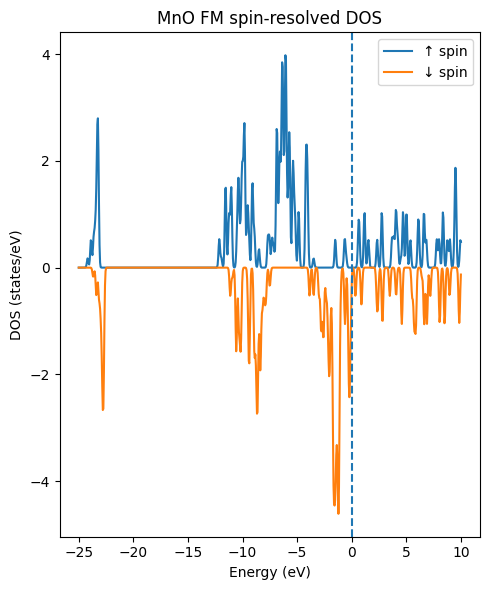

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Load DOS file produced by SIESTA
data = np.loadtxt("MnO_FM.DOS")

E = data[:,0]
up = data[:,1]
down = data[:,2]

plt.figure(figsize=(5,6))

plt.plot(E, up, label="↑ spin")
plt.plot(E, -down, label="↓ spin")  # negative for mirror view

plt.axvline(0, linestyle="--")  # Fermi level

plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states/eV)")
plt.title("MnO FM spin-resolved DOS")
plt.legend()
plt.tight_layout()
plt.show()


### PLot the resolved DOS for MnO using gnuplot

In [24]:
%%bash
gnuplot << 'EOF'
set terminal pngcairo size 600,500  # give the size of the image
set output "MnO_FM_DOS.png"  # save the image in form of png

set xlabel "Energy (eV)"
set ylabel "DOS (states/eV)"
set title "MnO FM Spin-Resolved DOS"

set key left top
set xzeroaxis
#plot section
plot "MnO_FM.DOS" u 1:2 w l title "spin up", \
     "MnO_FM.DOS" u 1:(-$3) w l title "spin down"

EOF


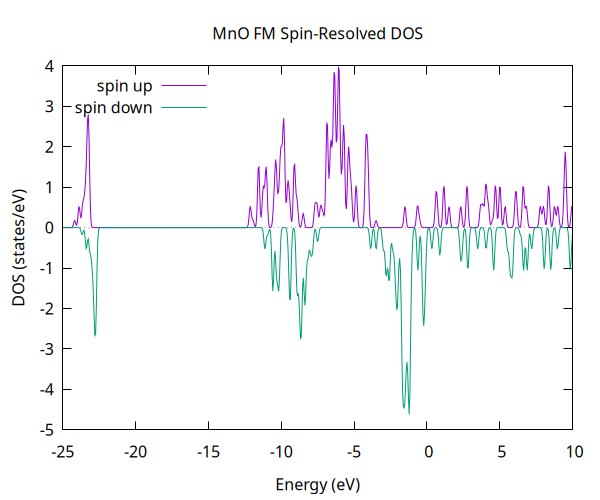

In [25]:
from IPython.display import Image
Image("MnO_FM_DOS.png")


## What we do and what we learn from the spin-resolved DOS

In this step, we run a **spin-polarized calculation** for MnO, generate the **density of states**, and plot **spin-up and spin-down DOS separately**. By comparing the two curves, we check whether the system is magnetic and how the electronic states are distributed in energy.

From the plot, we see that spin-up and spin-down DOS are different, which confirms **ferromagnetism** and explains the finite magnetic moment (~5 μB). The separation between the two spin channels shows **exchange splitting**, and the small DOS near the Fermi level indicates insulating/small-gap behavior. Thus, the DOS helps us directly connect **magnetic ordering with the electronic structure**.


In [26]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/magnetism/06_MnO


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [27]:
ls

Answers/  MnO_AF1.fdf  MnO_FM.fdf  O.psf           plot_PDOS.gplot
EX1_FM/   MnO_AF2.fdf  Mn.psf      plot_DOS.gplot  Untitled.ipynb


In [30]:
%%bash
# Create folders
mkdir -p AFM_1 AFM_2

FILES1="MnO_AF1.fdf O.psf Mn.psf"
FILES2="MnO_AF2.fdf O.psf Mn.psf"
# -------Anti-Ferromagnetic[001]------------------
cp $FILES1 AFM_1/
cd AFM_1

echo "Running AFM_1..."
siesta < MnO_AF1.fdf > MnO_AF1.out
cd ..

# ---------- Anti-Ferromagnetic[111] ------------
cp $FILES2 AFM_2/
cd AFM_2
echo "Running AFM_2..."
siesta < MnO_AF2.fdf > MnO_AF2.out
cd ..




Running AFM_1...


Job completed


Running AFM_2...


Job completed


In [31]:
ls

AFM_1/  Answers/  MnO_AF1.fdf  MnO_FM.fdf  O.psf           plot_PDOS.gplot
AFM_2/  EX1_FM/   MnO_AF2.fdf  Mn.psf      plot_DOS.gplot  Untitled.ipynb


### **Total Energies**

In [51]:
%%bash
echo "AFM_1:"
grep "Total =" AFM_1/MnO_AF1.out

printf '%*s\n' 40 '' | tr ' ' -        #or (echo "-----")

echo "AFM_2":
grep "Total =" AFM_2/MnO_AF2.out


AFM_1:
siesta:         Total =   -2092.609169
----------------------------------------
AFM_2:
siesta:         Total =   -2092.760017


### **Total Magnetic Moment**

In [48]:
%%bash
echo "AFM_1:"
grep "spin moment" AFM_1/MnO_AF1.out | tail -1

printf '%*s\n' 80 '' | tr ' ' -

echo "AFM_2:"
grep "spin moment" AFM_2/MnO_AF2.out | tail -1


AFM_1:
     spin moment: {S} , |S| = {        0.0        0.0   -0.00000 }    -0.00000
--------------------------------------------------------------------------------
AFM_2:
     spin moment: {S} , |S| = {        0.0        0.0   -0.00000 }    -0.00000


### **Mulliken Atomic Population**

In [64]:
%%bash 
echo "AFM_1"
grep -A10 "Mulliken Atomic Populations" AFM_1/MnO_AF1.out

printf '%*s\n' 80 ' ' | tr ' '  -

echo "AFM_2"
grep -A10 "Mulliken Atomic Populations" AFM_2/MnO_AF2.out

AFM_1
Mulliken Atomic Populations:
Atom #   charge [q] valence [e]      Sz [e]  Species
     1     0.730037    6.269963    4.887671  Mn
     2     0.730037    6.269963   -4.887671  Mn
     3    -0.730037    6.730037    0.058247  O
     4    -0.730037    6.730037   -0.058247  O
-------------------------------------------
 Total    -0.000000                0.000000

cite: Please indicate the Siesta version in published work: 5.4.2
cite: This calculation has made use of features in the following articles
--------------------------------------------------------------------------------
AFM_2
Mulliken Atomic Populations:
Atom #   charge [q] valence [e]      Sz [e]  Species
     1     0.723172    6.276828    4.715602  Mn
     2     0.723172    6.276828   -4.715602  Mn
     3    -0.723172    6.723172    0.000000  O
     4    -0.723172    6.723172   -0.000000  O
-------------------------------------------
 Total    -0.000000                0.000000

cite: Please indicate the Siesta version in p

In [66]:
%%bash
echo " AFM_1 "
sed -n '/mulliken: Spin UP/,/Qtot/p' AFM_1/MnO_AF1.out

printf '\n'

sed -n '/mulliken: Spin DOWN/,/Qtot/p' AFM_1/MnO_AF1.out

printf '\n===============================================================\n\n'

echo " AFM_2 "
sed -n '/mulliken: Spin UP/,/Qtot/p' AFM_2/MnO_AF2.out

printf '\n'

sed -n '/mulliken: Spin DOWN/,/Qtot/p' AFM_2/MnO_AF2.out


 AFM_1 
mulliken: Spin UP 

Species: Mn                  
Atom  Qatom  Qorb
               4s      4s      3dxy    3dyz    3dz2    3dxz    3dx2-y2 3dxy    
               3dyz    3dz2    3dxz    3dx2-y2 4Ppy    4Ppz    4Ppx    
   1  5.579   0.103   0.126   1.000   1.002   0.952   1.002   0.950  -0.015
             -0.027   0.039  -0.027   0.038   0.144   0.150   0.144
   2  0.691  -0.053   0.148   0.046   0.057   0.095   0.057   0.097  -0.011
             -0.014  -0.007  -0.014  -0.006   0.101   0.094   0.101

Species: O                   
Atom  Qatom  Qorb
               2s      2s      2py     2pz     2px     2py     2pz     2px     
               3Pdxy   3Pdyz   3Pdz2   3Pdxz   3Pdx2-y2
   3  3.394   0.917  -0.013   0.902   0.950   0.902  -0.083  -0.114  -0.083
              0.005   0.004   0.001   0.004   0.002
   4  3.336   0.916  -0.017   0.931   0.884   0.931  -0.117  -0.086  -0.117
              0.001   0.004   0.002   0.004   0.000

mulliken: Qtot =       13.000

mulliken: S

In [60]:
%%bash
gnuplot << 'EOF'
set terminal pngcairo size 1000,450
set output "AFM_subplots.png"

set multiplot layout 1,2 title "MnO Spin-Resolved DOS (AF1 vs AF2)"

set xlabel "Energy (eV)"
set ylabel "DOS"
set grid
set key left top

# SAME AXES FOR BOTH
set xrange [-14:5]
set yrange [-6:6]

# -------- AF1 --------
set title "AF1 [001]"
plot "AFM_1/MnO_AF1.DOS" u 1:2 w l lw 2 title "spin up", \
     "AFM_1/MnO_AF1.DOS" u 1:(-$3) w l lw 2 title "spin down"

# -------- AF2 --------
set title "AF2 [111]"
plot "AFM_2/MnO_AF2.DOS" u 1:2 w l lw 2 title "spin up", \
     "AFM_2/MnO_AF2.DOS" u 1:(-$3) w l lw 2 title "spin down"

unset multiplot
EOF


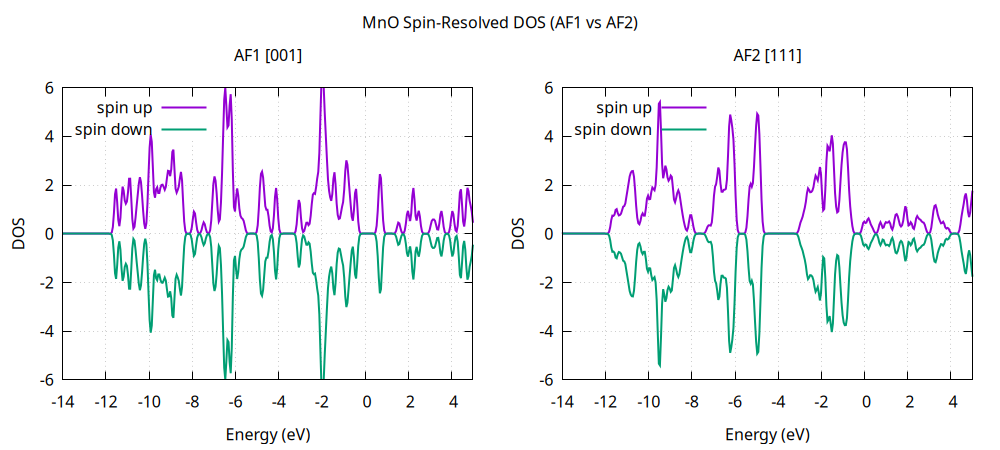

In [61]:
from IPython.display import Image
Image("AFM_subplots.png")


## **What we learn from this tutorial**

In this tutorial, we use spin-polarized SIESTA calculations to study how different magnetic orderings (FM, AF1, AF2) change the electronic structure of MnO. We run separate simulations for each magnetic phase, compute the total energy, magnetic moments, and plot the spin-resolved density of states (DOS).

By comparing the DOS, we learn that:
- FM → spin-up and spin-down are different → finite magnetic moment  
- AF → spin channels are symmetric → zero total moment  
- AF2 → lowest energy → true ground state  

Thus, we understand how magnetic ordering directly affects the band structure and DOS, and how to practically analyze magnetism using DFT outputs (energies, Mulliken moments, and DOS plots).
